# Deep Learning Models for Bridge Deck Evaluation Using Impact Echo

This notebook reproduces the training and testing result of 1D CNN. 

In [3]:
# Standard Data Science & Manipulation Libraries
import numpy as np
import pandas as pd
import os

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Processing
from scipy.fft import fft, fftfreq
from scipy import signal

# Deep Learning Framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms

# Machine Learning & Performance Metrics
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set plotting style
sns.set_theme(style="whitegrid")

## Data Loading & Exploration

The raw IE files are stored as text files containing exactly 2,000 data points per signal. Each file is structured with two columns of exponential floats:
* **Time (s)**
* **Voltage (V)**


In [4]:
# =========================================================
# 1. Hardware Check
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

# =========================================================
# 2. Data Aggregation
# =========================================================
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}\n")

# =========================================================
# 3. Dataset & Model Definition
# =========================================================
class IEDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        
        # CRITICAL FIX 1: Z-score normalization is mathematically required for the LSTM's Tanh gates
        voltage = (voltage - np.mean(voltage)) / (np.std(voltage) + 1e-8)
        
        voltage_tensor = torch.tensor(voltage).unsqueeze(-1)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return voltage_tensor, label_tensor

=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512



## 1D CNN Model

Because recurrent networks (like biLSTM) fundamentally struggle with vanishing gradients over long sequences, a **1D Convolutional Neural Network (1D CNN)** is further used for data training.

Unlike the biLSTM which processes data sequentially step-by-step, the 1D CNN processes the entire waveform simultaneously. Based exactly on **Figure 6** of the paper, the architecture maps out as follows:
* **CBR1:** 20 filters of size 200, padding='same' (Output: 2000 length x 20 channels).
* **MP1:** Max Pooling of 10 (Output: 200 length x 20 channels).
* **CBR2:** 200 filters of size 2, padding='valid' (Output: 199 length x 200 channels).
* **MP2:** Max Pooling of 2 (Output: 99 length x 200 channels).
* **CBR3:** 200 filters of size 4, padding='valid' (Output: 96 length x 200 channels).
* **FRD1 & FRD2:** Fully connected layers compressing 19,200 flattened features down to 1000, then 500, utilizing 50% Dropout.
* **FRD3:** Fully connected layer compressing 500 features down to 2 logits corresponding to the classification target classes.
* **Softmax:** Normalization layer converting the 2 raw logits into a calibrated probability distribution summing to 1.0.

In [5]:
import torch.nn as nn

# ---------------------------------------------------------
# Proposed 1D CNN Architecture (Strictly matching Figure 6)
# ---------------------------------------------------------
class IE_1D_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(IE_1D_CNN, self).__init__()
        
        # CBR1: Convolution, Batch Norm, ReLU
        # Input: 1 channel x 2000 length
        # Output: 20 channels x 2000 length
        self.cbr1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=20, kernel_size=200, padding='same'),
            nn.BatchNorm1d(20),
            nn.ReLU()
        )
        
        # MP1: Max Pooling (Reduces length from 2000 -> 200)
        self.mp1 = nn.MaxPool1d(kernel_size=10, stride=10) 
        
        # CBR2: Convolution, Batch Norm, ReLU
        # Output: 200 channels x 199 length
        self.cbr2 = nn.Sequential(
            nn.Conv1d(in_channels=20, out_channels=200, kernel_size=2, padding='valid'),
            nn.BatchNorm1d(200),
            nn.ReLU()
        )
        
        # MP2: Max Pooling (Reduces length from 199 -> 99)
        self.mp2 = nn.MaxPool1d(kernel_size=2, stride=2) 
        
        # CBR3: Convolution, Batch Norm, ReLU
        # Output: 200 channels x 96 length
        self.cbr3 = nn.Sequential(
            nn.Conv1d(in_channels=200, out_channels=200, kernel_size=4, padding='valid'),
            nn.BatchNorm1d(200),
            nn.ReLU()
        )
        
        # Calculate flattened size: 200 channels * 96 sequence length = 19200
        self.flatten = nn.Flatten()
        
        # FRD1: Fully Connected, ReLU, Dropout (Output: 1000)
        self.frd1 = nn.Sequential(
            nn.Linear(19200, 1000),
            nn.ReLU(),
            nn.Dropout(p=0.5) 
        )
        
        # FRD2: Fully Connected, ReLU, Dropout (Output: 500)
        self.frd2 = nn.Sequential(
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Dropout(p=0.5)
        )
        
        # FRD3 / Output Layer (Output: 2)
        self.output_layer = nn.Linear(500, num_classes)

    def forward(self, x):
        # PyTorch Conv1d expects shape: (batch_size, channels, sequence_length)
        # Our dataset outputs (batch, 2000, 1), so we permute to (batch, 1, 2000)
        x = x.permute(0, 2, 1)
        
        # Feature Extraction
        x = self.cbr1(x)
        x = self.mp1(x)
        
        x = self.cbr2(x)
        x = self.mp2(x)
        
        x = self.cbr3(x)
        
        # Flatten and Classify
        x = self.flatten(x)
        x = self.frd1(x)
        x = self.frd2(x)
        
        predictions = self.output_layer(x)
        return predictions

# Quick test to verify the CNN Architecture initializes correctly
cnn_test = IE_1D_CNN()
print("1D CNN Successfully Initialized!")

1D CNN Successfully Initialized!


## Model Training Protocol (1D CNN)

With our 1D CNN architecture defined, we will now execute the Leave-One-Specimen-Out (LOSO) cross-validation loop. 

According to **Table 3** in the paper, the 1D CNN requires hyperparameters as following:
* **Optimizer:** SGDM (Stochastic Gradient Descent with Momentum)
* **Learning Rate:** 1e-3
* **Mini Batch Size:** 50
* **Max Epochs:** 40

Because the 1D CNN processes the entire sequence in parallel (rather than step-by-step like the LSTM), this training loop will execute drastically faster on the GPU. We will also apply class weights to the loss function to account for the 3:1 data imbalance (Sound vs. Defected).

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. Training Protocol (1D CNN)
# =========================================================
EPOCHS = 40
BATCH_SIZE = 50
LR = 1e-3
MOMENTUM = 0.9 

cnn_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training 1D CNN: Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    # Split data (Leave-One-Specimen-Out)
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = IEDataset(train_files, train_labels)
    test_dataset = IEDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = IE_1D_CNN().to(device)
    
    # Dynamic Class Weighting to handle the Sound vs Defected imbalance (~3:1)
    num_sound = np.sum(train_labels == 0)
    num_defected = np.sum(train_labels == 1)
    weight_ratio = num_sound / num_defected
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # Calculate and store batch accuracy for the Iteration Plot
            _, preds = torch.max(outputs, 1)
            correct = (preds == targets).sum().item()
            batch_acc = (correct / targets.size(0)) * 100.0  
            iteration_accuracies[test_slab].append(batch_acc)
            
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    tn, fp, fn, tp = confusion_matrix(all_targs, all_preds).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    cnn_metrics['ACC'].append(acc)
    cnn_metrics['TPR'].append(tpr)
    cnn_metrics['TNR'].append(tnr)
    cnn_metrics['F1'].append(f1)

total_time = time.time() - total_start_time

# =========================================================
# 2. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total 1D CNN Training Time: {total_time/60:.2f} minutes")
print("=== Overall 1D CNN Performance Metrics ===")

for metric, values in cnn_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)
    
    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")



--- Training 1D CNN: Holding out Slab 1 for Testing ---


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


  Epoch [01/40] - Loss: 0.6551
  Epoch [10/40] - Loss: 0.1571
  Epoch [20/40] - Loss: 0.0128
  Epoch [30/40] - Loss: 0.0045
  Epoch [40/40] - Loss: 0.0013
  > Test Slab 1 Results - ACC: 0.90 | TPR: 0.78 | TNR: 0.94 | F1: 0.80
  > Fold completed in 150.7 seconds.

--- Training 1D CNN: Holding out Slab 2 for Testing ---
  Epoch [01/40] - Loss: 0.6703
  Epoch [10/40] - Loss: 0.1521
  Epoch [20/40] - Loss: 0.0118
  Epoch [30/40] - Loss: 0.0025
  Epoch [40/40] - Loss: 0.0013
  > Test Slab 2 Results - ACC: 0.90 | TPR: 0.77 | TNR: 0.94 | F1: 0.79
  > Fold completed in 142.5 seconds.

--- Training 1D CNN: Holding out Slab 3 for Testing ---
  Epoch [01/40] - Loss: 0.6614
  Epoch [10/40] - Loss: 0.1390
  Epoch [20/40] - Loss: 0.0130
  Epoch [30/40] - Loss: 0.0030
  Epoch [40/40] - Loss: 0.0015
  > Test Slab 3 Results - ACC: 0.89 | TPR: 0.75 | TNR: 0.94 | F1: 0.78
  > Fold completed in 145.0 seconds.

--- Training 1D CNN: Holding out Slab 4 for Testing ---
  Epoch [01/40] - Loss: 0.6600
  Epoch [


Generating Accuracy vs Iteration plot...


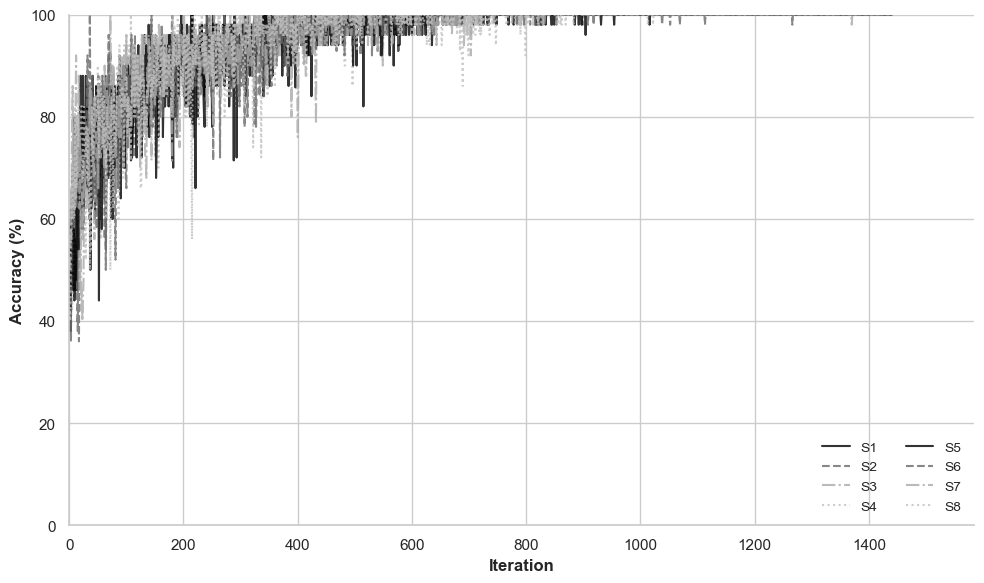

Plot saved successfully as 'cnn_1d_accuracy_vs_iteration.png'.


In [7]:
# =========================================================
# 3. Plotting Accuracy vs Iteration
# =========================================================
print("\nGenerating Accuracy vs Iteration plot...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

for slab_id in range(1, 9):
    acc_data = iteration_accuracies[slab_id]
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

# Add some padding to the x-axis for the legend to breathe
ax.set_xlim(0, len(iteration_accuracies[1]) * 1.1) 

# Clean up axes for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('cnn_1d_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'cnn_1d_accuracy_vs_iteration.png'.")